# Interactive Matplotlib Plot Workshop

Load a scenario once, compute the common plot inputs, then edit each plot directly in its own Matplotlib cell. These cells do not call the package plotting module; they save PDF files and show the Matplotlib output inline.

In [667]:
from pathlib import Path
import calendar
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "reserve_study").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from reserve_study import ReserveStudy

## Scenario

In [668]:
variant = "2026_joint_buget_maint"
projection_years = 30

study = ReserveStudy.from_directory(variant)
result = study.run(projection_years=projection_years)
result.write_outputs()

plots_dir = result.scenario.paths.plots_dir
plots_dir.mkdir(parents=True, exist_ok=True)

result.scenario.paths.output_root

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint')

## Plot Data

In [669]:
analysis_year = int(result.scenario.assumptions.analysis_year)
inflation = float(result.scenario.assumptions.inflation)

years = pd.DataFrame({
    "year": np.arange(analysis_year, analysis_year + projection_years, dtype=int),
})

reserve_projection = result.reserve_projection_df()

assessments = result.collection_schedule.annual_df().rename(columns={
    "contribution": "annual_contribution",
})
if assessments.empty:
    assessments = years.assign(annual_contribution=0.0, special_assessment=0.0)
for column in ["annual_contribution", "special_assessment"]:
    if column not in assessments.columns:
        assessments[column] = 0.0
    assessments[column] = pd.to_numeric(assessments[column], errors="coerce").fillna(0.0)
assessments["year"] = pd.to_numeric(assessments["year"], errors="coerce")
assessments = assessments.dropna(subset=["year"]).copy()
assessments["year"] = assessments["year"].astype(int)

expenditures = result.expenditures_summary_df().rename(columns={
    "replacement_year": "year",
})
if expenditures.empty:
    expenditures = years.assign(expenditures=0.0)
expenditures["year"] = pd.to_numeric(expenditures["year"], errors="coerce")
expenditures = expenditures.dropna(subset=["year"]).copy()
expenditures["year"] = expenditures["year"].astype(int)
expenditures["expenditures"] = pd.to_numeric(expenditures["expenditures"], errors="coerce").fillna(0.0)

plot_df = years.merge(
    assessments[["year", "annual_contribution", "special_assessment"]],
    on="year",
    how="left",
)
plot_df = plot_df.merge(
    expenditures[["year", "expenditures"]],
    on="year",
    how="left",
)
plot_df[["annual_contribution", "special_assessment", "expenditures"]] = plot_df[
    ["annual_contribution", "special_assessment", "expenditures"]
].fillna(0.0)
plot_df["total_contributions"] = plot_df["annual_contribution"] + plot_df["special_assessment"]
inflation_factor = (1.0 + inflation) ** (plot_df["year"] - analysis_year)
plot_df["total_contributions_real"] = plot_df["total_contributions"] / inflation_factor
plot_df["expenditures_real"] = plot_df["expenditures"] / inflation_factor
plot_df["cumulative_contributions"] = plot_df["total_contributions"].cumsum()
plot_df["cumulative_contributions_real"] = plot_df["total_contributions_real"].cumsum()
plot_df["cumulative_expenditures"] = plot_df["expenditures"].cumsum()

plot_df.head()

,year,annual_contribution,special_assessment,expenditures,total_contributions,total_contributions_real,expenditures_real,cumulative_contributions,cumulative_contributions_real,cumulative_expenditures
0,2026,250000.0,0.0,601204.12,250000.0,250000.000000,601204.120000,250000.0,2.500000e+05,601204.12
1,2027,300000.0,0.0,257404.54,300000.0,291262.135922,249907.320388,550000.0,5.412621e+05,858608.66
2,2028,350000.0,0.0,327684.84,350000.0,329908.568197,308874.389669,900000.0,8.711707e+05,1186293.50
3,2029,400000.0,0.0,205164.40,400000.0,366056.663741,187754.489456,1300000.0,1.237227e+06,1391457.90
4,2030,450000.0,0.0,210283.29,450000.0,399819.171562,186833.979558,1750000.0,1.637047e+06,1601741.19


In [670]:
reserve_projection.head()

,year,begin_balance,contribution,special_assessment,expenditures,interest,end_balance,funded_balance,percent_funded
0,2026,620000.00,250000.0,0.0,601204.12,12801.56,281597.44,3040186.45,9.26
1,2027,281597.44,300000.0,0.0,257404.54,8522.37,332715.27,3224469.34,10.32
2,2028,332715.27,350000.0,0.0,327684.84,9762.20,364792.63,3358136.43,10.86
3,2029,364792.63,400000.0,0.0,205164.40,12537.25,572165.48,3631243.13,15.76
4,2030,572165.48,450000.0,0.0,210283.29,18410.13,830292.32,3913935.06,21.21


## Small Helpers

In [671]:
money_formatter = mtick.StrMethodFormatter("${x:,.0f}")


def save_pdf(fig, filename):
    path = plots_dir / filename
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible")
        fig.tight_layout()
    fig.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    return path


def find_milestone_info(df, annual_col, fraction, timeline_start, timeline_end):
    target = df[annual_col].sum() * fraction
    running_before = 0.0

    for _, row in df.iterrows():
        year = int(row["year"])
        annual_val = float(row[annual_col])
        running_after = running_before + annual_val

        if running_after >= target:
            frac_through_year = 0.0 if annual_val == 0 else (target - running_before) / annual_val
            crossing_x = year + frac_through_year
            month_num = min(max(int(frac_through_year * 12) + 1, 1), 12)
            crossing_month_year = f"{calendar.month_name[month_num]} {year}"
            timeline_fraction_x = timeline_start + (timeline_end - timeline_start) * fraction
            delta_years = crossing_x - timeline_fraction_x
            abs_years = abs(delta_years)
            whole_years = int(abs_years)
            whole_months = int(round((abs_years - whole_years) * 12))

            if whole_months == 12:
                whole_years += 1
                whole_months = 0

            if abs_years < 1 / 24:
                timing_text = "On time"
            elif delta_years < 0:
                timing_text = f"{whole_years} years, {whole_months} months early"
            else:
                timing_text = f"{whole_years} years, {whole_months} months late"

            return {"x": crossing_x, "month_year": crossing_month_year, "timing_text": timing_text}

        running_before = running_after

    return {"x": None, "month_year": None, "timing_text": None}

## Reserve Contributions Over Time

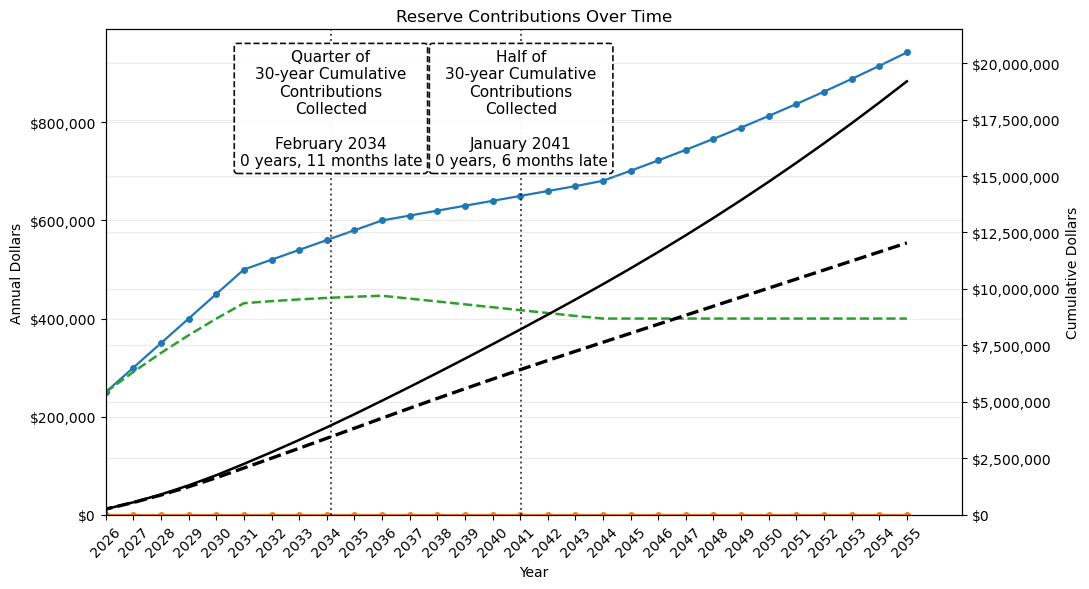

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/reserve_contributions_over_time.pdf')

In [672]:
base_year = analysis_year
last_year = int(plot_df["year"].max())

cumulative_real = plot_df[["year", "total_contributions_real"]].copy()
cumulative_real["cumulative_contributions_real"] = cumulative_real["total_contributions_real"].cumsum()
cumulative_nominal = plot_df[["year", "total_contributions"]].copy()
cumulative_nominal["cumulative_contributions"] = cumulative_nominal["total_contributions"].cumsum()

cumulative_real = pd.concat([
    pd.DataFrame({"year": [base_year], "total_contributions_real": [0.0], "cumulative_contributions_real": [0.0]}),
    cumulative_real,
], ignore_index=True)
cumulative_nominal = pd.concat([
    pd.DataFrame({"year": [base_year], "total_contributions": [0.0], "cumulative_contributions": [0.0]}),
    cumulative_nominal,
], ignore_index=True)

quarter_info = find_milestone_info(plot_df, "total_contributions_real", 0.25, base_year, last_year)
half_info = find_milestone_info(plot_df, "total_contributions_real", 0.50, base_year, last_year)

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

ax.plot(plot_df["year"], plot_df["annual_contribution"], marker="o", markersize=4, linewidth=1.6, color=colors[0])
ax.plot(plot_df["year"], plot_df["special_assessment"], marker="o", markersize=4, linewidth=1.6, color=colors[1])
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=1.8, linestyle="--", color=colors[2])
ax2.plot(cumulative_nominal["year"], cumulative_nominal["cumulative_contributions"], color="black", linewidth=1.8)
ax2.plot(cumulative_real["year"], cumulative_real["cumulative_contributions_real"], color="black", linewidth=2.4, linestyle="--")

ax.set_ylim(bottom=0)
cum_max = max(cumulative_nominal["cumulative_contributions"].max(), cumulative_real["cumulative_contributions_real"].max())
ax2.set_ylim(0, cum_max * 1.12 if cum_max else 1.0)

bbox_style = {
    "boxstyle": "round,pad=0.35,rounding_size=0.2",
    "facecolor": "white",
    "edgecolor": "black",
    "linestyle": "--",
    "linewidth": 1.2,
    "alpha": 0.95,
}
for info, headline in [
    (quarter_info, "Quarter of\n30-year Cumulative\nContributions\nCollected"),
    (half_info, "Half of\n30-year Cumulative\nContributions\nCollected"),
]:
    if info["x"] is None:
        continue
    ax2.axvline(x=info["x"], color="black", linewidth=1.4, linestyle=":", alpha=0.7)
    ax2.annotate(
        f'{headline}\n\n{info["month_year"]}\n{info["timing_text"]}',
        xy=(info["x"], ax2.get_ylim()[1] * 0.96),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="top",
        multialignment="center",
        fontsize=11,
        color="black",
        bbox=bbox_style,
    )

ax.set_title("Reserve Contributions Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Dollars")
ax2.set_ylabel("Cumulative Dollars")
all_years = sorted(set(cumulative_nominal["year"]).union(set(cumulative_real["year"])))
ax.set_xticks(all_years)
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(base_year, plot_df["year"].max() + 2)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax2.grid(True, axis="y", alpha=0.25)

save_pdf(fig, "reserve_contributions_over_time.pdf")

## Nominal Contributions and Monthly Per-Unit Contributions

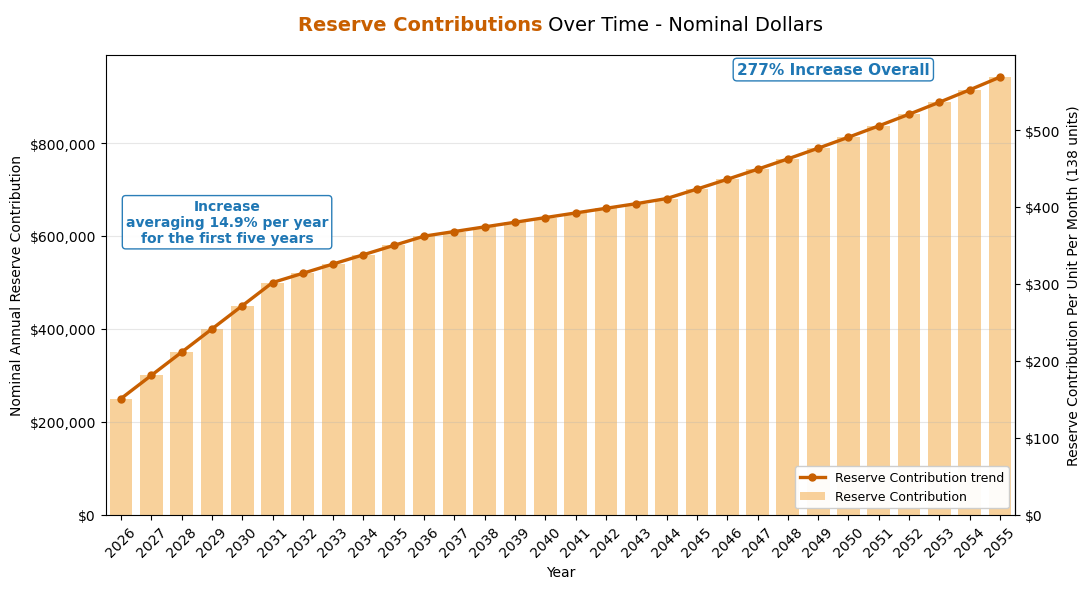

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/nominal_contributions_and_monthly_per_unit.pdf')

In [673]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))

nominal_plot = plot_df[["year", "annual_contribution"]].copy()

fig, ax = plt.subplots(figsize=(11, 6))

light_orange = "#f6c27a"
dark_orange = "#c85f00"

ax.bar(
    nominal_plot["year"],
    nominal_plot["annual_contribution"],
    width=0.75,
    color=light_orange,
    alpha=0.75,
    label="Reserve Contribution",
)
ax.plot(
    nominal_plot["year"],
    nominal_plot["annual_contribution"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=dark_orange,
    markerfacecolor=dark_orange,
    markeredgecolor=dark_orange,
    label="Reserve Contribution trend",
)

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis(
    "right",
    functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual),
)

ax.set_title("")
title = HPacker(
    children=[
        TextArea(
            "Reserve Contributions",
            textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " Over Time - Nominal Dollars",
            textprops={"color": "black", "fontsize": 14},
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)
title_box = AnchoredOffsetbox(
    loc="upper center",
    child=title,
    bbox_to_anchor=(0.5, 1.10),
    bbox_transform=ax.transAxes,
    frameon=False,
    borderpad=0,
)
ax.add_artist(title_box)
ax.set_xlabel("Year")
ax.set_ylabel("Nominal Annual Reserve Contribution")
ax2.set_ylabel(f"Reserve Contribution Per Unit Per Month ({units:,} units)")
ax.set_xticks(nominal_plot["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(nominal_plot["year"].min() - 0.5, nominal_plot["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(nominal_plot["year"].min())
fifth_year = first_year + 5
first_five_values = nominal_plot.loc[
    nominal_plot["year"].between(first_year, fifth_year),
    ["year", "annual_contribution"],
].sort_values("year")
first_five_year_average_increase = first_five_values["annual_contribution"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year + 2) / 2
first_five_window = nominal_plot[
    nominal_plot["year"].between(first_year, fifth_year)
]
first_five_annotation_y = first_five_window["annual_contribution"].max() * 1.16
ax.annotate(
    f"Increase\naveraging {first_five_year_average_increase:.1f}% per year\nfor the first five years",
    xy=(first_five_annotation_x, first_five_annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

start_reserve = float(nominal_plot.loc[nominal_plot["year"] == 2026, "annual_contribution"].iloc[0])
end_reserve = float(nominal_plot.loc[nominal_plot["year"] == 2055, "annual_contribution"].iloc[0])
percent_increase = (end_reserve / start_reserve - 1) * 100
annotation_x = (2044 + 2055) / 2
plateau = nominal_plot[
    nominal_plot["year"].between(2044, 2055)
]
annotation_y = plateau["annual_contribution"].max() * 1.00
ax.annotate(
    f"{percent_increase:.0f}% Increase Overall",
    xy=(annotation_x, annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "nominal_contributions_and_monthly_per_unit.pdf")

## Reserve and Operating Contributions

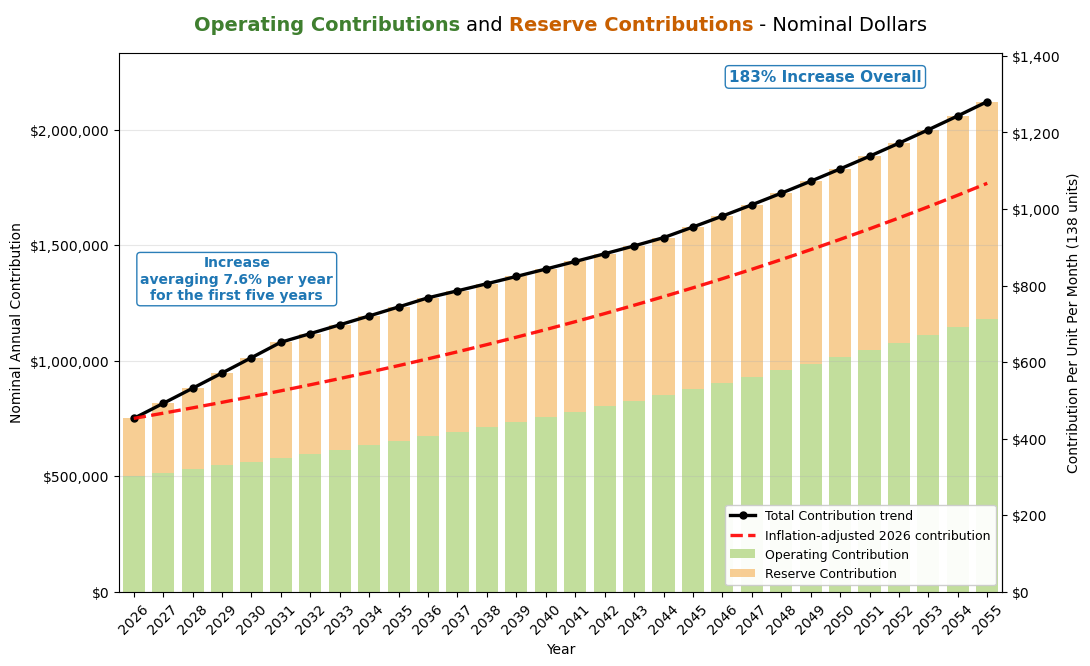

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/reserve_and_operating_contributions.pdf')

In [674]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))

contribution_stack = plot_df[["year", "annual_contribution"]].copy()
contribution_stack["operating_contribution"] = 500_000 * (1.03 ** (contribution_stack["year"] - 2026))
contribution_stack["total_contribution"] = (
    contribution_stack["operating_contribution"] + contribution_stack["annual_contribution"]
)

reserve_axis_max = contribution_stack["annual_contribution"].max() * 1.1
stacked_axis_max = contribution_stack["total_contribution"].max() * 1.1
height_scale = stacked_axis_max / reserve_axis_max if reserve_axis_max else 1.0
fig_height = min(8.5, 3 * height_scale)

fig, ax = plt.subplots(figsize=(11, fig_height))

light_orange = "#f6c27a"
dark_orange = "#c85f00"
light_green = "#b8d98b"
dark_green = "#3f7f2f"
total_trend_color = "black"

ax.bar(
    contribution_stack["year"],
    contribution_stack["operating_contribution"],
    width=0.75,
    color=light_green,
    alpha=0.85,
    label="Operating Contribution",
)
ax.bar(
    contribution_stack["year"],
    contribution_stack["annual_contribution"],
    width=0.75,
    bottom=contribution_stack["operating_contribution"],
    color=light_orange,
    alpha=0.8,
    label="Reserve Contribution",
)
ax.plot(
    contribution_stack["year"],
    contribution_stack["total_contribution"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=total_trend_color,
    markerfacecolor=total_trend_color,
    markeredgecolor=total_trend_color,
    label="Total Contribution trend",
)

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis(
    "right",
    functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual),
)

ax.set_title("")
title = HPacker(
    children=[
        TextArea(
            "Operating Contributions",
            textprops={"color": dark_green, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " and ",
            textprops={"color": "black", "fontsize": 14},
        ),
        TextArea(
            "Reserve Contributions",
            textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " - Nominal Dollars",
            textprops={"color": "black", "fontsize": 14},
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)
title_box = AnchoredOffsetbox(
    loc="upper center",
    child=title,
    bbox_to_anchor=(0.5, 1.08),
    bbox_transform=ax.transAxes,
    frameon=False,
    borderpad=0,
)
ax.add_artist(title_box)
ax.set_xlabel("Year")
ax.set_ylabel("Nominal Annual Contribution")
ax2.set_ylabel(f"Contribution Per Unit Per Month ({units:,} units)")
ax.set_xticks(contribution_stack["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(contribution_stack["year"].min() - 0.5, contribution_stack["year"].max() + 0.5)
ax.set_ylim(0, stacked_axis_max)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(contribution_stack["year"].min())
fifth_year = first_year + 5
first_five_values = contribution_stack.loc[
    contribution_stack["year"].between(first_year, fifth_year),
    ["year", "total_contribution"],
].sort_values("year")
first_five_year_average_increase = first_five_values["total_contribution"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year + 2) / 2
first_five_window = contribution_stack[
    contribution_stack["year"].between(first_year, fifth_year)
]
first_five_annotation_y = first_five_window["total_contribution"].max() * 1.16
ax.annotate(
    f"Increase\naveraging {first_five_year_average_increase:.1f}% per year\nfor the first five years",
    xy=(first_five_annotation_x, first_five_annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

start_combined = float(contribution_stack.loc[contribution_stack["year"] == 2026, "total_contribution"].iloc[0])
end_combined = float(contribution_stack.loc[contribution_stack["year"] == 2055, "total_contribution"].iloc[0])
percent_increase = (end_combined / start_combined - 1) * 100
annotation_x = (2044 + 2055) / 2
plateau = contribution_stack[
    contribution_stack["year"].between(2044, 2055)
]
annotation_y = plateau["total_contribution"].max() * 1.035
ax.annotate(
    f"{percent_increase:.0f}% Increase Overall",
    xy=(annotation_x, annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

inflation_only_start_value = float(
    contribution_stack.loc[
        contribution_stack["year"] == 2026,
        "total_contribution",
    ].iloc[0]
)
inflation_only_line = contribution_stack[["year"]].copy()
inflation_only_line = inflation_only_line[inflation_only_line["year"] >= 2026].copy()
inflation_only_line["inflation_adjusted_2026_contribution"] = inflation_only_start_value * (
    1.03 ** (inflation_only_line["year"] - 2026)
)
ax.plot(
    inflation_only_line["year"],
    inflation_only_line["inflation_adjusted_2026_contribution"],
    color="red",
    linestyle="--",
    linewidth=2.4,
    alpha=0.9,
    label="Inflation-adjusted 2026 contribution",
)

ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_and_operating_contributions.pdf")

## Reserve Contributions in 2026 Purchasing Power

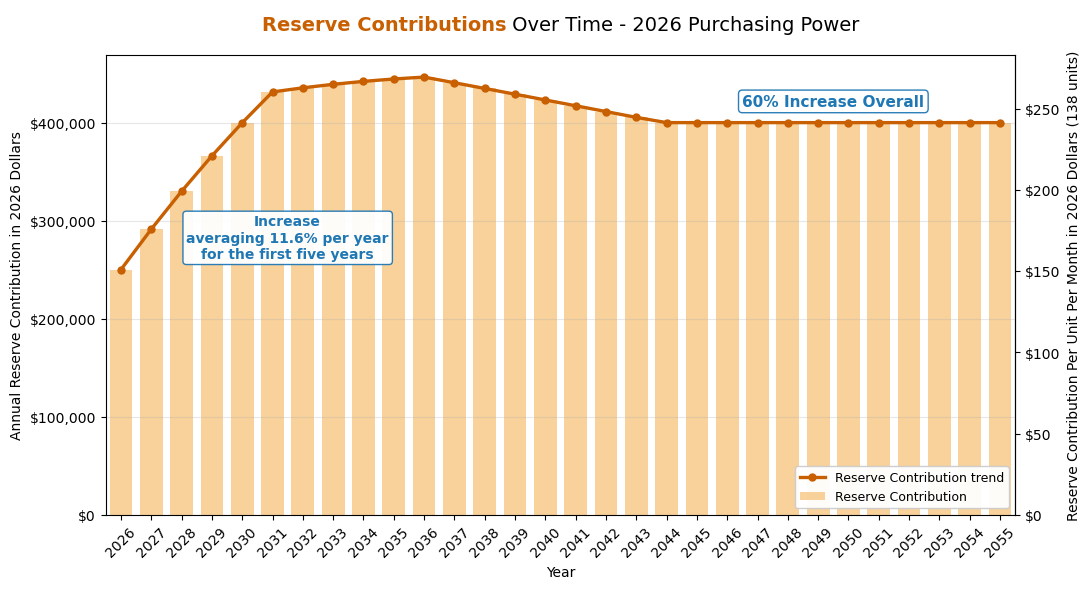

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/reserve_contributions_2026_purchasing_power.pdf')

In [675]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))
real_inflation = 0.03
base_purchasing_power_year = 2026

real_reserve_plot = plot_df[["year", "annual_contribution"]].copy()
real_reserve_plot["annual_contribution_2026_dollars"] = real_reserve_plot["annual_contribution"] / (
    (1 + real_inflation) ** (real_reserve_plot["year"] - base_purchasing_power_year)
)

fig, ax = plt.subplots(figsize=(11, 6))

light_orange = "#f6c27a"
dark_orange = "#c85f00"

ax.bar(
    real_reserve_plot["year"],
    real_reserve_plot["annual_contribution_2026_dollars"],
    width=0.75,
    color=light_orange,
    alpha=0.75,
    label="Reserve Contribution",
)
ax.plot(
    real_reserve_plot["year"],
    real_reserve_plot["annual_contribution_2026_dollars"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=dark_orange,
    markerfacecolor=dark_orange,
    markeredgecolor=dark_orange,
    label="Reserve Contribution trend",
)

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis(
    "right",
    functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual),
)

ax.set_title("")
title = HPacker(
    children=[
        TextArea(
            "Reserve Contributions",
            textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " Over Time - 2026 Purchasing Power",
            textprops={"color": "black", "fontsize": 14},
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)
title_box = AnchoredOffsetbox(
    loc="upper center",
    child=title,
    bbox_to_anchor=(0.5, 1.10),
    bbox_transform=ax.transAxes,
    frameon=False,
    borderpad=0,
)
ax.add_artist(title_box)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Contribution in 2026 Dollars")
ax2.set_ylabel(f"Reserve Contribution Per Unit Per Month in 2026 Dollars ({units:,} units)")
ax.set_xticks(real_reserve_plot["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(real_reserve_plot["year"].min() - 0.5, real_reserve_plot["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(real_reserve_plot["year"].min())
fifth_year = first_year + 5
first_five_values = real_reserve_plot.loc[
    real_reserve_plot["year"].between(first_year, fifth_year),
    ["year", "annual_contribution_2026_dollars"],
].sort_values("year")
first_five_year_average_increase = first_five_values["annual_contribution_2026_dollars"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year+6) / 2
first_five_window = real_reserve_plot[
    real_reserve_plot["year"].between(first_year, fifth_year)
]
first_five_annotation_y = first_five_window["annual_contribution_2026_dollars"].max() * 0.60
ax.annotate(
    f"Increase\naveraging {first_five_year_average_increase:.1f}% per year\nfor the first five years",
    xy=(first_five_annotation_x, first_five_annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

start_reserve = float(real_reserve_plot.loc[real_reserve_plot["year"] == 2026, "annual_contribution_2026_dollars"].iloc[0])
end_reserve = float(real_reserve_plot.loc[real_reserve_plot["year"] == 2055, "annual_contribution_2026_dollars"].iloc[0])
percent_increase = (end_reserve / start_reserve - 1) * 100
annotation_x = (2044 + 2055) / 2
plateau = real_reserve_plot[
    real_reserve_plot["year"].between(2044, 2055)
]
annotation_y = plateau["annual_contribution_2026_dollars"].max() * 1.035
ax.annotate(
    f"{percent_increase:.0f}% Increase Overall",
    xy=(annotation_x, annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_contributions_2026_purchasing_power.pdf")

## Reserve and Operating Contributions in 2026 Purchasing Power

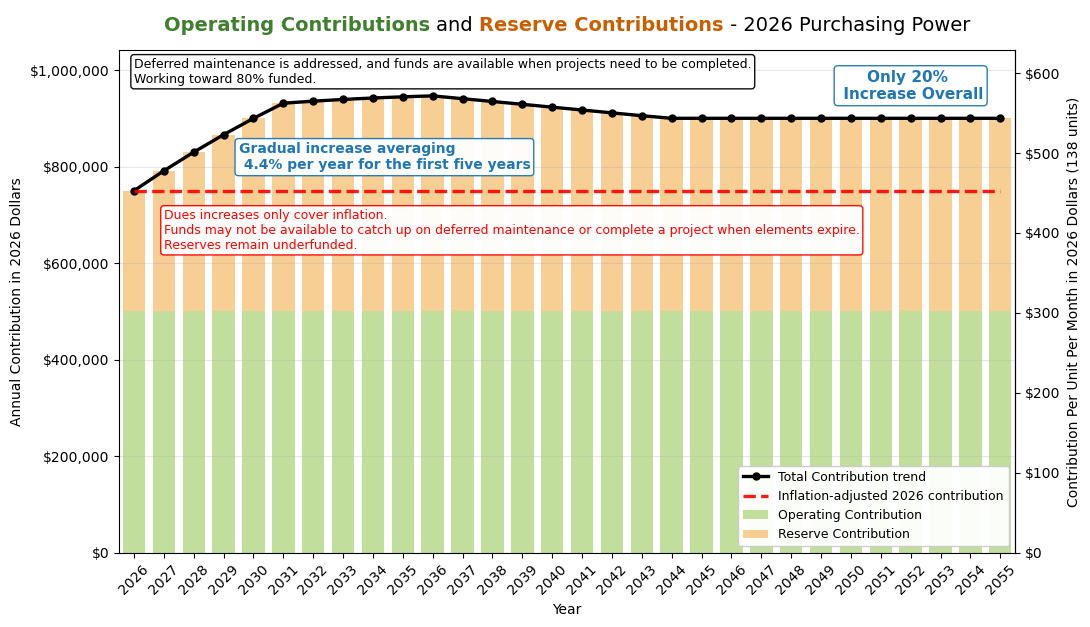

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/reserve_and_operating_contributions_2026_purchasing_power.pdf')

In [689]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))
real_inflation = 0.03
base_purchasing_power_year = 2026

real_stack = plot_df[["year", "annual_contribution"]].copy()
real_stack["operating_contribution"] = 500_000 * (1.03 ** (real_stack["year"] - 2026))
real_stack["inflation_factor_to_2026"] = (1 + real_inflation) ** (
    real_stack["year"] - base_purchasing_power_year
)
real_stack["reserve_contribution_2026_dollars"] = (
    real_stack["annual_contribution"] / real_stack["inflation_factor_to_2026"]
)
real_stack["operating_contribution_2026_dollars"] = (
    real_stack["operating_contribution"] / real_stack["inflation_factor_to_2026"]
)
real_stack["total_contribution_2026_dollars"] = (
    real_stack["operating_contribution_2026_dollars"] + real_stack["reserve_contribution_2026_dollars"]
)

reserve_axis_max = real_stack["reserve_contribution_2026_dollars"].max() * 1.1
stacked_axis_max = real_stack["total_contribution_2026_dollars"].max() * 1.1
height_scale = stacked_axis_max / reserve_axis_max if reserve_axis_max else 1.0
fig_height = min(8.5, 3 * height_scale)

fig, ax = plt.subplots(figsize=(11, fig_height))

light_orange = "#f6c27a"
dark_orange = "#c85f00"
light_green = "#b8d98b"
dark_green = "#3f7f2f"
total_trend_color = "black"

ax.bar(
    real_stack["year"],
    real_stack["operating_contribution_2026_dollars"],
    width=0.75,
    color=light_green,
    alpha=0.85,
    label="Operating Contribution",
)
ax.bar(
    real_stack["year"],
    real_stack["reserve_contribution_2026_dollars"],
    width=0.75,
    bottom=real_stack["operating_contribution_2026_dollars"],
    color=light_orange,
    alpha=0.8,
    label="Reserve Contribution",
)
ax.plot(
    real_stack["year"],
    real_stack["total_contribution_2026_dollars"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=total_trend_color,
    markerfacecolor=total_trend_color,
    markeredgecolor=total_trend_color,
    label="Total Contribution trend",
)

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis(
    "right",
    functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual),
)

ax.set_title("")
title = HPacker(
    children=[
        TextArea(
            "Operating Contributions",
            textprops={"color": dark_green, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " and ",
            textprops={"color": "black", "fontsize": 14},
        ),
        TextArea(
            "Reserve Contributions",
            textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " - 2026 Purchasing Power",
            textprops={"color": "black", "fontsize": 14},
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)
title_box = AnchoredOffsetbox(
    loc="upper center",
    child=title,
    bbox_to_anchor=(0.5, 1.08),
    bbox_transform=ax.transAxes,
    frameon=False,
    borderpad=0,
)
ax.add_artist(title_box)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Contribution in 2026 Dollars")
ax2.set_ylabel(f"Contribution Per Unit Per Month in 2026 Dollars ({units:,} units)")
ax.set_xticks(real_stack["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(real_stack["year"].min() - 0.5, real_stack["year"].max() + 0.5)
ax.set_ylim(0, stacked_axis_max)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(real_stack["year"].min())
fifth_year = first_year + 5
first_five_values = real_stack.loc[
    real_stack["year"].between(first_year, fifth_year),
    ["year", "total_contribution_2026_dollars"],
].sort_values("year")
first_five_year_average_increase = first_five_values["total_contribution_2026_dollars"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year +2 ) / 2
first_five_window = real_stack[
    real_stack["year"].between(first_year, fifth_year)
]
first_five_annotation_y = first_five_window["total_contribution_2026_dollars"].max() * 0.88
ax.annotate(
    f"Gradual increase averaging\n {first_five_year_average_increase:.1f}% per year for the first five years",
    xy=(first_five_annotation_x, first_five_annotation_y),
    ha="left",
    va="center",
    color="#1f77b4",
    fontweight="bold",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

start_combined = float(real_stack.loc[real_stack["year"] == 2026, "total_contribution_2026_dollars"].iloc[0])
end_combined = float(real_stack.loc[real_stack["year"] == 2055, "total_contribution_2026_dollars"].iloc[0])
percent_increase = (end_combined / start_combined - 1) * 100
annotation_x = 2052
plateau = real_stack[
    real_stack["year"].between(2044, 2055)
]
annotation_y = plateau["total_contribution_2026_dollars"].max() * 1.075
ax.annotate(
    f"Only {percent_increase:.0f}% \n Increase Overall",
    xy=(annotation_x, annotation_y),
    ha="center",
    va="center",
    color="#1f77b4",
    fontweight="bold",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

policy_text_fontsize = 9
inflation_only_value = float(
    real_stack.loc[
        real_stack["year"] == 2026,
        "total_contribution_2026_dollars",
    ].iloc[0]
)
inflation_only_line = real_stack[["year"]].copy()
inflation_only_line = inflation_only_line[inflation_only_line["year"] >= 2026].copy()
inflation_only_line["inflation_adjusted_2026_contribution"] = inflation_only_value
ax.plot(
    inflation_only_line["year"],
    inflation_only_line["inflation_adjusted_2026_contribution"],
    color="red",
    linestyle="--",
    linewidth=2.4,
    alpha=0.9,
    label="Inflation-adjusted 2026 contribution",
)
ax.annotate(
    "Dues increases only cover inflation.\n"
    "Funds may not be available to catch up on deferred maintenance or complete a project when elements expire.\n"
    "Reserves remain underfunded.",
    xy=(2027, inflation_only_value * 0.95),
    ha="left",
    va="top",
    color="red",
    fontsize=policy_text_fontsize,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "red",
        "alpha": 0.95,
    },
)
ax.annotate(
    "Deferred maintenance is addressed, and funds are available when projects need to be completed.\n"
    "Working toward 80% funded.",
    xy=(2026, inflation_only_value * 1.29),
    ha="left",
    va="bottom",
    color="black",
    fontsize=policy_text_fontsize,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "black",
        "alpha": 0.95,
    },
)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_and_operating_contributions_2026_purchasing_power.pdf")

## Expenditures and Total Contributions

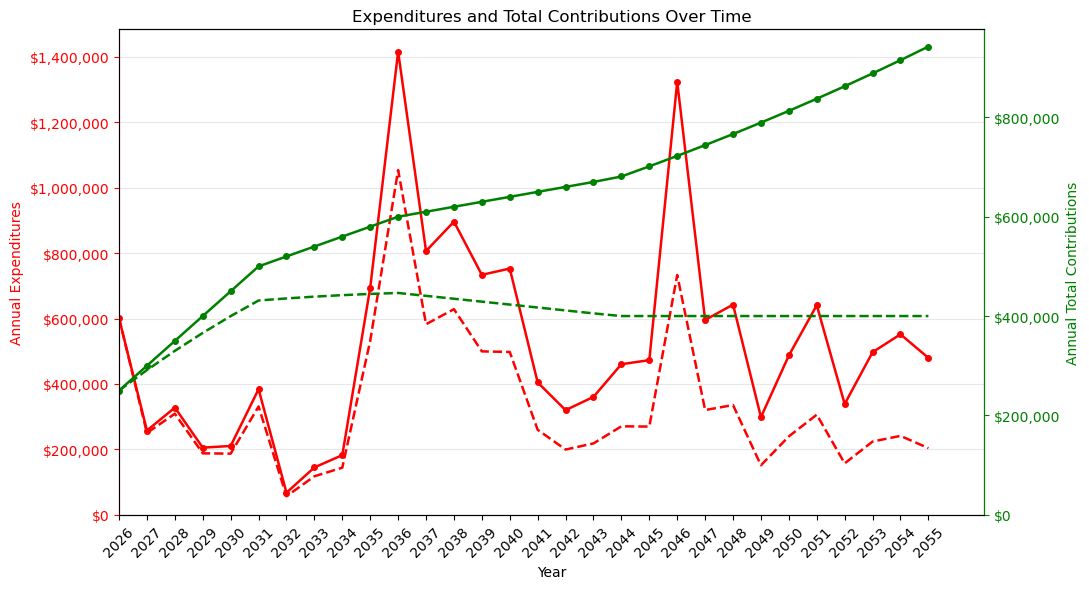

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/expenditures_and_total_contributions.pdf')

In [677]:
fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()

exp_color = "red"
contrib_color = "green"

ax.plot(plot_df["year"], plot_df["expenditures"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=exp_color)
ax.plot(plot_df["year"], plot_df["expenditures_real"], linewidth=1.8, linestyle="--", color=exp_color)
ax2.plot(plot_df["year"], plot_df["total_contributions"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=contrib_color)
ax2.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=1.8, linestyle="--", color=contrib_color)

ax.set_title("Expenditures and Total Contributions Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Expenditures", color=exp_color)
ax2.set_ylabel("Annual Total Contributions", color=contrib_color)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.set_xticks(sorted(plot_df["year"].unique()))
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=exp_color)
ax2.tick_params(axis="y", colors=contrib_color)
ax.spines["left"].set_color(exp_color)
ax2.spines["right"].set_color(contrib_color)
ax.yaxis.label.set_color(exp_color)
ax2.yaxis.label.set_color(contrib_color)
ax.set_xlim(plot_df["year"].min(), plot_df["year"].max() + 2)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

save_pdf(fig, "expenditures_and_total_contributions.pdf")

## Annual and Cumulative Expenditures vs. Contributions

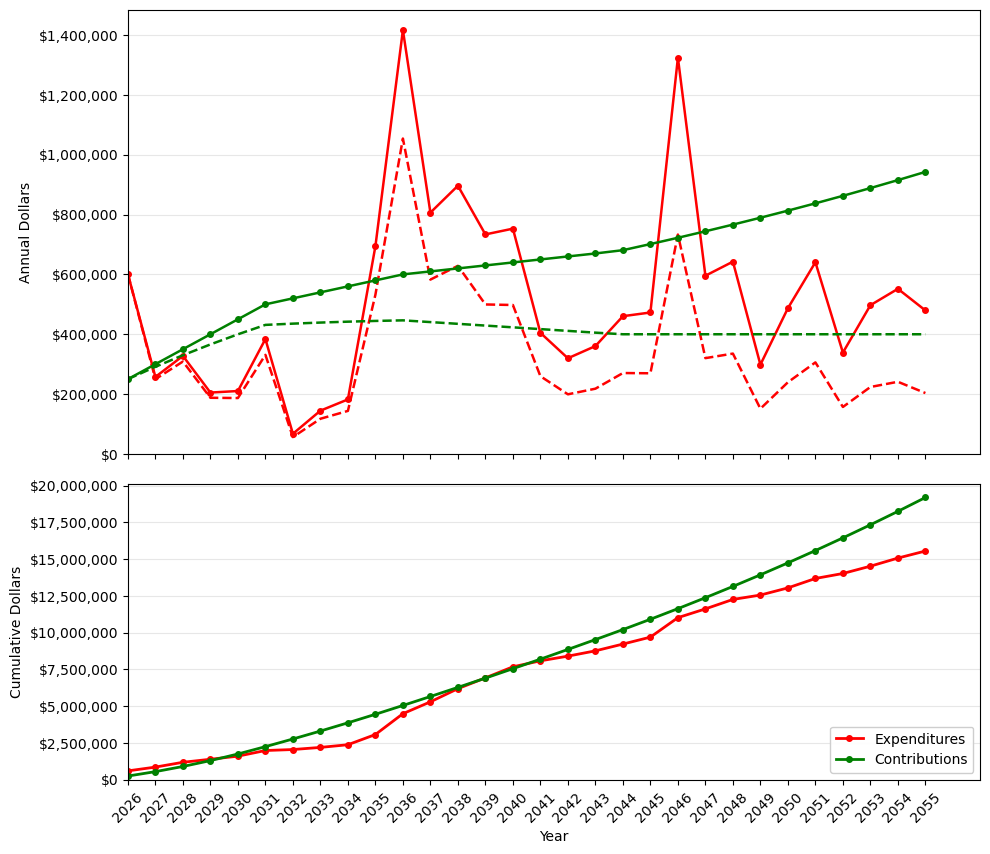

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/annual_and_cumulative_expenditures_vs_contributions.pdf')

In [678]:
exp_color = "red"
contrib_color = "green"

fig, (ax, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(11, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08},
)

ax.plot(plot_df["year"], plot_df["expenditures"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=exp_color)
ax.plot(plot_df["year"], plot_df["expenditures_real"], linewidth=1.8, linestyle="--", color=exp_color)
ax.plot(plot_df["year"], plot_df["total_contributions"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=contrib_color)
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=1.8, linestyle="--", color=contrib_color)
ax.set_ylabel("Annual Dollars")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

line_exp, = ax_bottom.plot(plot_df["year"], plot_df["cumulative_expenditures"], marker="o", markersize=4, linewidth=2.0, linestyle="-", color=exp_color, label="Expenditures")
line_contrib, = ax_bottom.plot(plot_df["year"], plot_df["cumulative_contributions"], marker="o", markersize=4, linewidth=2.0, linestyle="-", color=contrib_color, label="Contributions")
ax_bottom.set_xlabel("Year")
ax_bottom.set_ylabel("Cumulative Dollars")
ax_bottom.set_ylim(bottom=0)
ax_bottom.yaxis.set_major_formatter(money_formatter)
ax_bottom.grid(True, axis="y", alpha=0.3)
ax_bottom.set_xticks(sorted(plot_df["year"].unique()))
ax_bottom.tick_params(axis="x", rotation=45)
ax_bottom.set_xlim(plot_df["year"].min(), plot_df["year"].max() + 2)
ax_bottom.legend(handles=[line_exp, line_contrib], loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "annual_and_cumulative_expenditures_vs_contributions.pdf")

## Annual and Cumulative Reserve Contributions

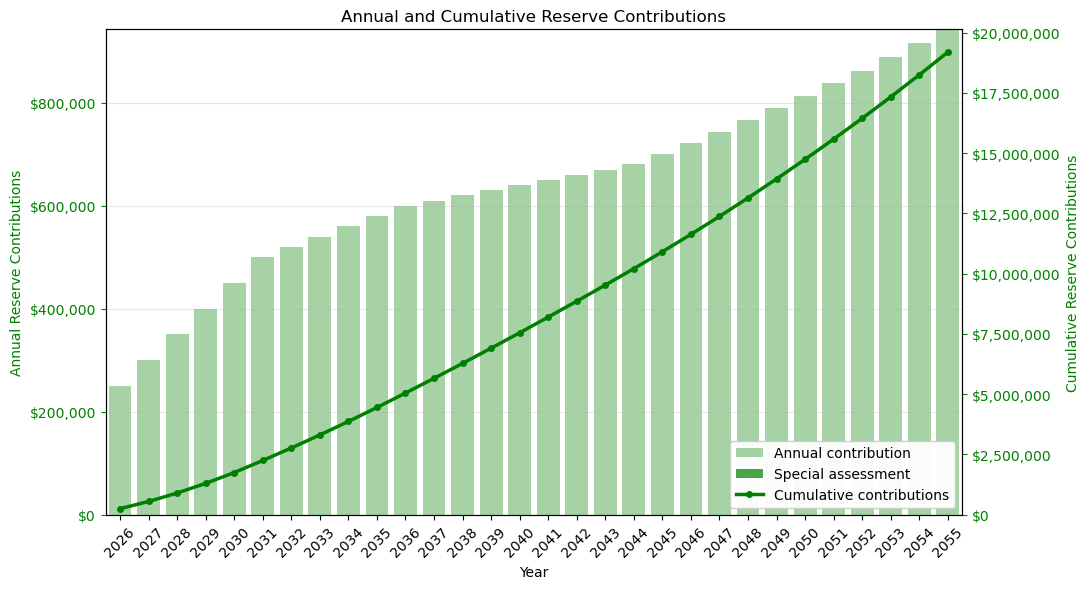

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/annual_and_cumulative_reserve_contributions.pdf')

In [679]:
fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()
green = "green"

ax.bar(plot_df["year"], plot_df["annual_contribution"], width=0.8, color=green, alpha=0.35, label="Annual contribution")
ax.bar(plot_df["year"], plot_df["special_assessment"], width=0.8, bottom=plot_df["annual_contribution"], color=green, alpha=0.7, label="Special assessment")
ax2.plot(plot_df["year"], plot_df["cumulative_contributions"], color=green, linewidth=2.5, marker="o", markersize=4, label="Cumulative contributions")

ax.set_title("Annual and Cumulative Reserve Contributions")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Contributions", color=green)
ax2.set_ylabel("Cumulative Reserve Contributions", color=green)
ax.set_xticks(plot_df["year"])
ax.set_xlim(plot_df["year"].min() - 0.5, plot_df["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=green)
ax2.tick_params(axis="y", colors=green)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "annual_and_cumulative_reserve_contributions.pdf")

## Annual and Cumulative Contributions and Expenditures

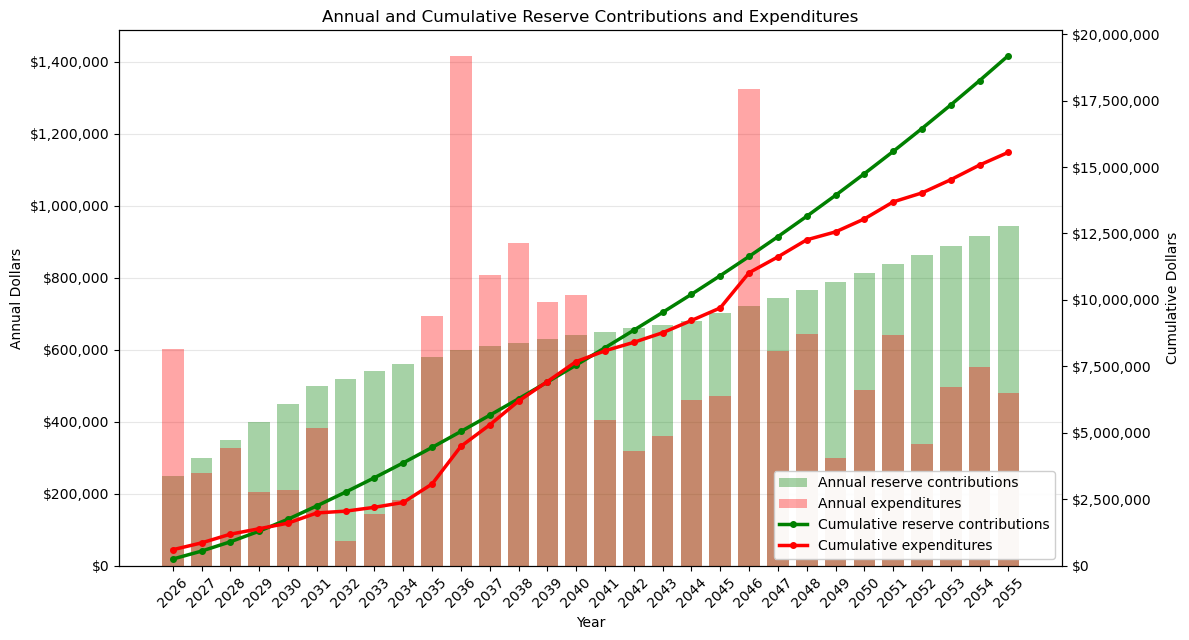

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/annual_and_cumulative_contributions_and_expenditures.pdf')

In [680]:
green = "green"
red = "red"

fig, ax = plt.subplots(figsize=(12, 6.5))
ax2 = ax.twinx()

ax.bar(plot_df["year"], plot_df["total_contributions"], width=0.75, color=green, alpha=0.35, label="Annual reserve contributions", zorder=2)
ax.bar(plot_df["year"], plot_df["expenditures"], width=0.75, color=red, alpha=0.35, label="Annual expenditures", zorder=3)
ax2.plot(plot_df["year"], plot_df["cumulative_contributions"], color=green, linewidth=2.5, marker="o", markersize=4, label="Cumulative reserve contributions", zorder=4)
ax2.plot(plot_df["year"], plot_df["cumulative_expenditures"], color=red, linewidth=2.5, marker="o", markersize=4, label="Cumulative expenditures", zorder=5)

ax.set_title("Annual and Cumulative Reserve Contributions and Expenditures")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Dollars")
ax2.set_ylabel("Cumulative Dollars")
ax.set_xticks(plot_df["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "annual_and_cumulative_contributions_and_expenditures.pdf")

## The Big Six and Reserve Balance

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)

planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

# Specific project families override broader source categories.
maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)

reserve_balance_plot = reserve_projection[["year", "end_balance"]].copy()
reserve_balance_plot["year"] = pd.to_numeric(reserve_balance_plot["year"], errors="coerce").astype(int)
reserve_balance_plot["end_balance"] = pd.to_numeric(
    reserve_balance_plot["end_balance"],
    errors="coerce",
).fillna(0.0)

fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}

bar_bottom = np.zeros(len(maintenance_matrix))
for category in planning_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.75,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.85,
        label=category,
    )
    bar_bottom += values

ax2.plot(
    reserve_balance_plot["year"],
    reserve_balance_plot["end_balance"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
)

ax.set_title("The Big Six and Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Expenditures")
ax2.set_ylabel("Year-End Reserve Balance")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_big_components_and_reserve_balance.pdf")

## The Big Six and Reserve Balance

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)

planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

# Specific project families override broader source categories.
maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)
reserve_balance_plot = reserve_projection[["year", "end_balance"]].copy()
reserve_balance_plot["year"] = pd.to_numeric(reserve_balance_plot["year"], errors="coerce").astype(int)
reserve_balance_plot["end_balance"] = pd.to_numeric(
    reserve_balance_plot["end_balance"],
    errors="coerce",
).fillna(0.0)

maintenance_matrix = maintenance_matrix.merge(reserve_balance_plot, on="year", how="left")
maintenance_matrix["end_balance"] = maintenance_matrix["end_balance"].fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}
bar_bottom = np.zeros(len(maintenance_matrix))
for category in planning_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.75,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.85,
        label=category,
    )
    bar_bottom += values

ax2.plot(
    reserve_balance_plot["year"],
    reserve_balance_plot["end_balance"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
)

ax.set_title("The Big Six and Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Expenditures")
ax2.set_ylabel("")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_selected_categories_and_reserve_balance.pdf")

## The Big Six and Reserve Balance in 2026 Dollars

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail["future_cost_2026_dollars"] = maintenance_detail["future_cost"] / (
    1.03 ** (maintenance_detail["replacement_year"] - 2026)
)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)

planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

# Specific project families override broader source categories.
maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost_2026_dollars"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost_2026_dollars",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)
reserve_balance_plot = reserve_projection[["year", "end_balance"]].copy()
reserve_balance_plot["year"] = pd.to_numeric(reserve_balance_plot["year"], errors="coerce").astype(int)
reserve_balance_plot["end_balance"] = pd.to_numeric(
    reserve_balance_plot["end_balance"],
    errors="coerce",
).fillna(0.0)
reserve_balance_plot["end_balance_2026_dollars"] = reserve_balance_plot["end_balance"] / (
    1.03 ** (reserve_balance_plot["year"] - 2026)
)

maintenance_matrix = maintenance_matrix.merge(reserve_balance_plot, on="year", how="left")
maintenance_matrix["end_balance_2026_dollars"] = maintenance_matrix["end_balance_2026_dollars"].fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}
bar_bottom = np.zeros(len(maintenance_matrix))
for category in planning_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.75,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.85,
        label=category,
    )
    bar_bottom += values

ax2.plot(
    reserve_balance_plot["year"],
    reserve_balance_plot["end_balance_2026_dollars"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
)

ax.set_title("The Big Six and Reserve Balance - 2026 Dollars")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Expenditures in 2026 Dollars")
ax2.set_ylabel("")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_selected_categories_and_reserve_balance_2026_dollars.pdf")

## The Big Six: Pull-Forward Capacity and Reserve Balance

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)

planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

# Specific project families override broader source categories.
maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]
named_project_categories = planning_categories

category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)

reserve_cash_flow = reserve_projection[[
    "year",
    "contribution",
    "special_assessment",
    "interest",
    "end_balance",
]].copy()
reserve_cash_flow["year"] = pd.to_numeric(reserve_cash_flow["year"], errors="coerce").astype(int)
for column in ["contribution", "special_assessment", "interest", "end_balance"]:
    reserve_cash_flow[column] = pd.to_numeric(reserve_cash_flow[column], errors="coerce").fillna(0.0)

maintenance_matrix = maintenance_matrix.merge(reserve_cash_flow, on="year", how="left")
for column in ["contribution", "special_assessment", "interest", "end_balance"]:
    maintenance_matrix[column] = maintenance_matrix[column].fillna(0.0)
maintenance_matrix["annual_pull_forward_capacity"] = (
    maintenance_matrix["contribution"]
    + maintenance_matrix["special_assessment"]
    + maintenance_matrix["interest"]
).clip(lower=0.0)

fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

capacity_color = "#2ca02c"
ax.bar(
    maintenance_matrix["year"],
    maintenance_matrix["annual_pull_forward_capacity"],
    width=0.86,
    facecolor=capacity_color,
    edgecolor=capacity_color,
    alpha=0.16,
    linewidth=2.0,
    label="Annual Pull-Forward Capacity",
    zorder=1,
)

bar_bottom = np.zeros(len(maintenance_matrix))
for category in named_project_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.62,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.9,
        label=category,
        zorder=3,
    )
    bar_bottom += values

ax2.plot(
    maintenance_matrix["year"],
    maintenance_matrix["end_balance"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
    zorder=4,
)

ax.set_title("The Big Six: Pull-Forward Capacity and Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Projects and Pull-Forward Capacity")
ax2.set_ylabel("Year-End Reserve Balance")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=8,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_pull_forward_capacity.pdf")

## The Big Six: Pull-Forward Capacity and Reserve Balance in 2026 Dollars

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)

planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

# Specific project families override broader source categories.
maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]
named_project_categories = planning_categories

category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}

maintenance_detail["future_cost_2026_dollars"] = maintenance_detail["future_cost"] / (
    1.03 ** (maintenance_detail["year"] - 2026)
)
maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost_2026_dollars"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost_2026_dollars",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)

reserve_cash_flow = reserve_projection[[
    "year",
    "contribution",
    "special_assessment",
    "interest",
    "end_balance",
]].copy()
reserve_cash_flow["year"] = pd.to_numeric(reserve_cash_flow["year"], errors="coerce").astype(int)
for column in ["contribution", "special_assessment", "interest", "end_balance"]:
    reserve_cash_flow[column] = pd.to_numeric(reserve_cash_flow[column], errors="coerce").fillna(0.0)
for column in ["contribution", "special_assessment", "interest", "end_balance"]:
    reserve_cash_flow[f"{column}_2026_dollars"] = reserve_cash_flow[column] / (
        1.03 ** (reserve_cash_flow["year"] - 2026)
    )

maintenance_matrix = maintenance_matrix.merge(reserve_cash_flow, on="year", how="left")
for column in ["contribution_2026_dollars", "special_assessment_2026_dollars", "interest_2026_dollars", "end_balance_2026_dollars"]:
    maintenance_matrix[column] = maintenance_matrix[column].fillna(0.0)
maintenance_matrix["annual_pull_forward_capacity"] = (
    maintenance_matrix["contribution_2026_dollars"]
    + maintenance_matrix["special_assessment_2026_dollars"]
    + maintenance_matrix["interest_2026_dollars"]
).clip(lower=0.0)

fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

capacity_color = "#2ca02c"
ax.bar(
    maintenance_matrix["year"],
    maintenance_matrix["annual_pull_forward_capacity"],
    width=0.86,
    facecolor=capacity_color,
    edgecolor=capacity_color,
    alpha=0.16,
    linewidth=2.0,
    label="Annual Pull-Forward Capacity",
    zorder=1,
)

bar_bottom = np.zeros(len(maintenance_matrix))
for category in named_project_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.62,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.9,
        label=category,
        zorder=3,
    )
    bar_bottom += values

ax2.plot(
    maintenance_matrix["year"],
    maintenance_matrix["end_balance_2026_dollars"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
    zorder=4,
)

ax.set_title("The Big Six: Pull-Forward Capacity and Reserve Balance - 2026 Dollars")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Projects and Pull-Forward Capacity in 2026 Dollars")
ax2.set_ylabel("Year-End Reserve Balance in 2026 Dollars")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=8,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_pull_forward_capacity_2026_dollars.pdf")

## The Big Six: Category Share Pie Chart

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)
maintenance_detail = maintenance_detail[maintenance_detail["year"].isin(plot_df["year"].astype(int))].copy()

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]
category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}

category_totals = (
    maintenance_detail.groupby("planning_category")["future_cost"]
    .sum()
    .reindex(planning_categories, fill_value=0.0)
)
category_totals = category_totals[category_totals > 0]
colors = [category_colors[category] for category in category_totals.index]

fig, ax = plt.subplots(figsize=(10, 7.5))
wedges, texts, autotexts = ax.pie(
    category_totals,
    labels=category_totals.index,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.0},
    textprops={"fontsize": 9},
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color("black")

ax.set_title("The Big Six: Share of Planned Reserve Expenditures")
ax.axis("equal")

save_pdf(fig, "maintenance_planning_category_share_pie.pdf")

## The Big Six: Category Share Pie Chart in 2026 Dollars

In [ ]:
maintenance_detail = result.expenditures_detail_df().copy()
maintenance_detail["replacement_year"] = pd.to_numeric(
    maintenance_detail["replacement_year"],
    errors="coerce",
)
maintenance_detail["future_cost"] = pd.to_numeric(
    maintenance_detail["future_cost"],
    errors="coerce",
).fillna(0.0)
maintenance_detail = maintenance_detail.dropna(subset=["replacement_year"]).copy()
maintenance_detail["year"] = maintenance_detail["replacement_year"].astype(int)
maintenance_detail = maintenance_detail[maintenance_detail["year"].isin(plot_df["year"].astype(int))].copy()

component_text = (
    maintenance_detail["category"].astype(str) + " "
    + maintenance_detail["subcategory"].astype(str) + " "
    + maintenance_detail["component"].astype(str)
).str.lower()

maintenance_category_map = {
    "Roofing": "Sloped Roofs",
    "Asphalt": "Paving",
    "Painting": "Painting",
    "Balconies-Decks-Stairways": "Decking/Balconies",
    "Equipment": "HVAC Systems",
    "Structural": "Structural Components",
    "Exterior Surfaces": "Structural Components",
}
maintenance_detail["planning_category"] = maintenance_detail["category"].map(
    maintenance_category_map
).fillna("Other")

maintenance_detail.loc[component_text.str.contains("garage flat roof", na=False), "planning_category"] = "Garage Roofs"
maintenance_detail.loc[component_text.str.contains("siding", na=False), "planning_category"] = "Siding"
maintenance_detail.loc[
    component_text.str.contains("fascia|flashing|soffit", na=False),
    "planning_category",
] = "Fascia-Flashing-Soffits"
maintenance_detail.loc[
    component_text.str.contains("chimney chase", na=False),
    "planning_category",
] = "Chimney Chase Renovation"
maintenance_detail.loc[component_text.str.contains("carport", na=False), "planning_category"] = "Carport"

planning_categories = [
    "Sloped Roofs",
    "Garage Roofs",
    "Paving",
    "Painting",
    "Decking/Balconies",
    "HVAC Systems",
    "Structural Components",
    "Siding",
    "Fascia-Flashing-Soffits",
    "Chimney Chase Renovation",
    "Carport",
    "Other",
]
category_colors = {
    "Sloped Roofs": "#1f77b4",
    "Garage Roofs": "#ff7f0e",
    "Paving": "#2ca02c",
    "Painting": "#d62728",
    "Decking/Balconies": "#9467bd",
    "HVAC Systems": "#17becf",
    "Structural Components": "#8c564b",
    "Siding": "#e377c2",
    "Fascia-Flashing-Soffits": "#bcbd22",
    "Chimney Chase Renovation": "#7f7f7f",
    "Carport": "#aec7e8",
    "Other": "#c7c7c7",
}

maintenance_detail["future_cost_2026_dollars"] = maintenance_detail["future_cost"] / (
    1.03 ** (maintenance_detail["year"] - 2026)
)
category_totals = (
    maintenance_detail.groupby("planning_category")["future_cost_2026_dollars"]
    .sum()
    .reindex(planning_categories, fill_value=0.0)
)
category_totals = category_totals[category_totals > 0]
colors = [category_colors[category] for category in category_totals.index]

fig, ax = plt.subplots(figsize=(10, 7.5))
wedges, texts, autotexts = ax.pie(
    category_totals,
    labels=category_totals.index,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.0},
    textprops={"fontsize": 9},
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color("black")

ax.set_title("The Big Six: Share of Planned Reserve Expenditures - 2026 Dollars")
ax.axis("equal")

save_pdf(fig, "maintenance_planning_category_share_pie_2026_dollars.pdf")

## Reserve Balance

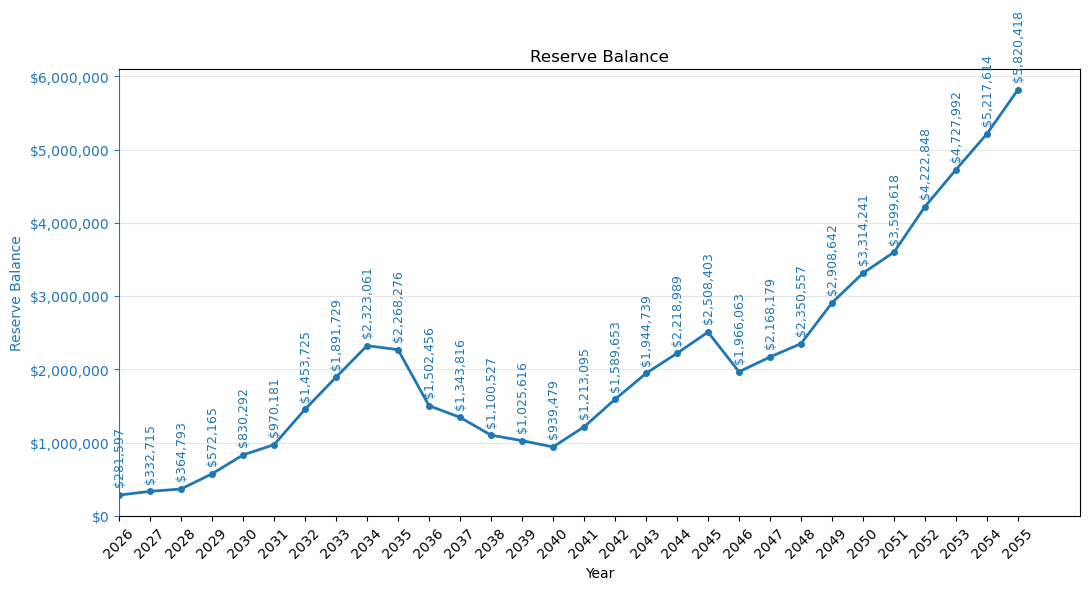

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/reserve_balance.pdf')

In [681]:
proj = reserve_projection.copy()
proj["year"] = pd.to_numeric(proj["year"], errors="coerce")
proj["end_balance"] = pd.to_numeric(proj["end_balance"], errors="coerce")
proj = proj.dropna(subset=["year", "end_balance"]).copy()
proj["year"] = proj["year"].astype(int)
proj = proj.sort_values("year").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
balance_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]

ax.plot(proj["year"], proj["end_balance"], marker="o", markersize=4, linewidth=2.0, linestyle="-", color=balance_color)
ax.set_title("Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Reserve Balance", color=balance_color)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=balance_color)
ax.spines["left"].set_color(balance_color)
ax.yaxis.label.set_color(balance_color)
ax.set_xticks(proj["year"])
ax.set_xlim(proj["year"].min(), proj["year"].max() + 2)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

for _, row in proj.iterrows():
    ax.annotate(
        f'${row["end_balance"]:,.0f}',
        xy=(row["year"], row["end_balance"]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9,
        color=balance_color,
    )

save_pdf(fig, "reserve_balance.pdf")

## Contributions Detail

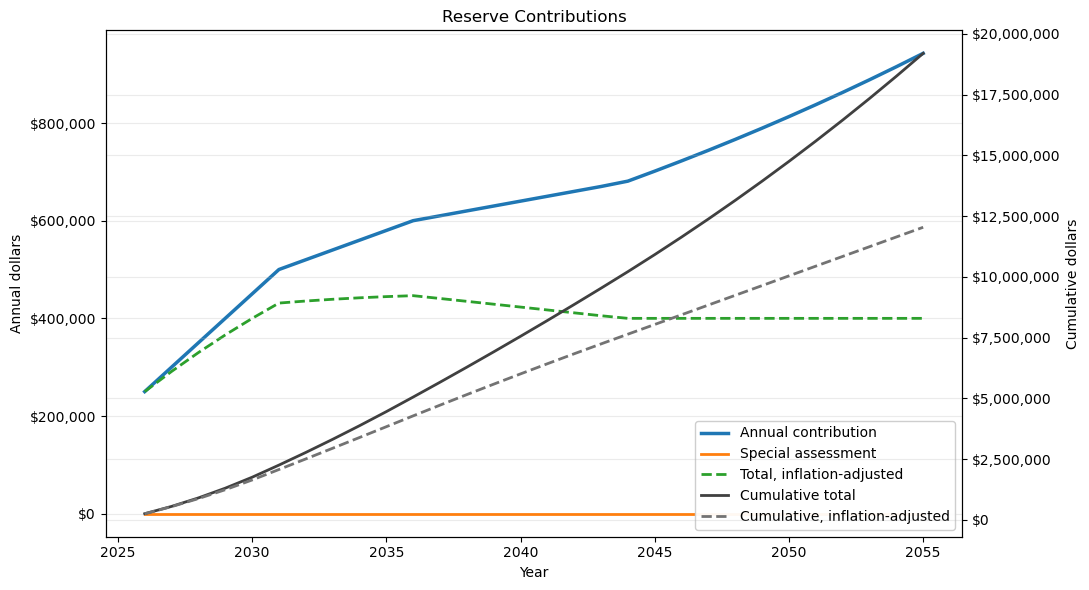

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/contributions_detail.pdf')

In [682]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(plot_df["year"], plot_df["annual_contribution"], linewidth=2.5, label="Annual contribution")
ax.plot(plot_df["year"], plot_df["special_assessment"], linewidth=2.0, label="Special assessment")
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=2.0, linestyle="--", label="Total, inflation-adjusted")

ax2 = ax.twinx()
ax2.plot(plot_df["year"], plot_df["cumulative_contributions"], color="0.25", linewidth=2.0, label="Cumulative total")
ax2.plot(plot_df["year"], plot_df["cumulative_contributions_real"], color="0.45", linewidth=2.0, linestyle="--", label="Cumulative, inflation-adjusted")

ax.set_title("Reserve Contributions")
ax.set_xlabel("Year")
ax.set_ylabel("Annual dollars")
ax2.set_ylabel("Cumulative dollars")
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax2.grid(True, axis="y", alpha=0.25)

lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [line.get_label() for line in lines], loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "contributions_detail.pdf")

## Expenditures vs. Contributions Detail

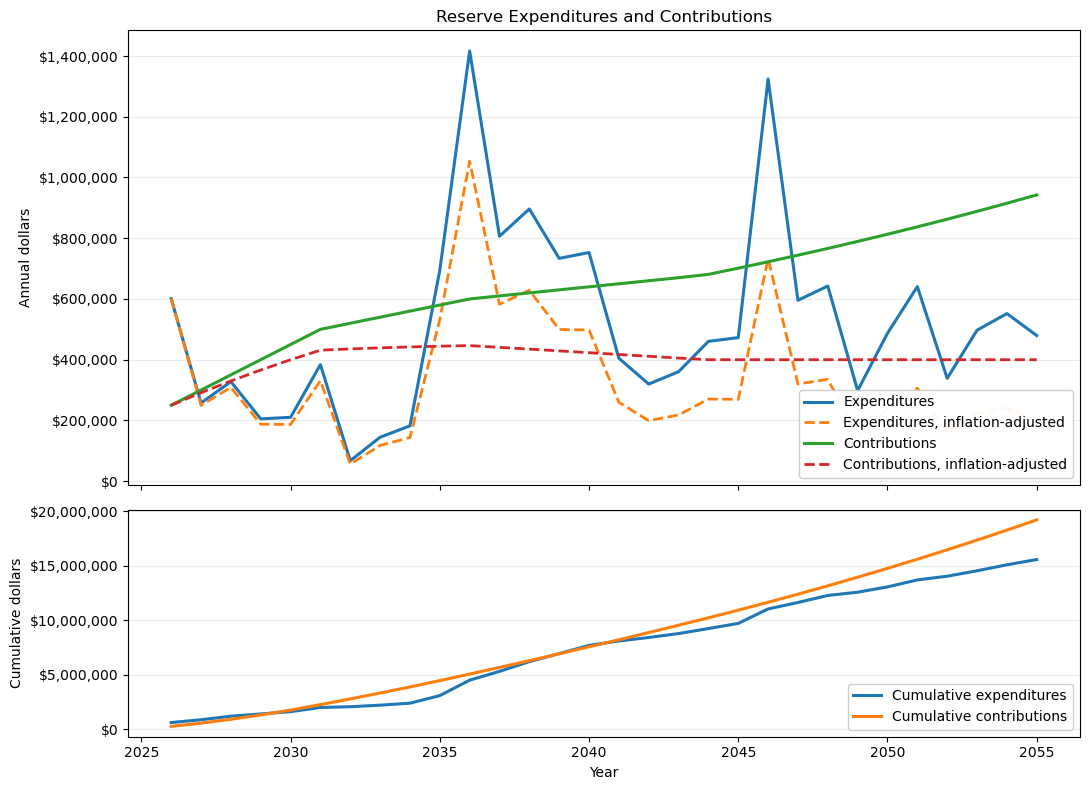

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/expenditures_vs_contributions_detail.pdf')

In [683]:
fig, (ax, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.plot(plot_df["year"], plot_df["expenditures"], linewidth=2.2, label="Expenditures")
ax.plot(plot_df["year"], plot_df["expenditures_real"], linewidth=2.0, linestyle="--", label="Expenditures, inflation-adjusted")
ax.plot(plot_df["year"], plot_df["total_contributions"], linewidth=2.2, label="Contributions")
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=2.0, linestyle="--", label="Contributions, inflation-adjusted")

ax_bottom.plot(plot_df["year"], plot_df["cumulative_expenditures"], linewidth=2.2, label="Cumulative expenditures")
ax_bottom.plot(plot_df["year"], plot_df["cumulative_contributions"], linewidth=2.2, label="Cumulative contributions")

ax.set_title("Reserve Expenditures and Contributions")
ax.set_ylabel("Annual dollars")
ax_bottom.set_xlabel("Year")
ax_bottom.set_ylabel("Cumulative dollars")
ax.yaxis.set_major_formatter(money_formatter)
ax_bottom.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax_bottom.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
ax_bottom.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "expenditures_vs_contributions_detail.pdf")

## Reserve Balance vs. Fully Funded

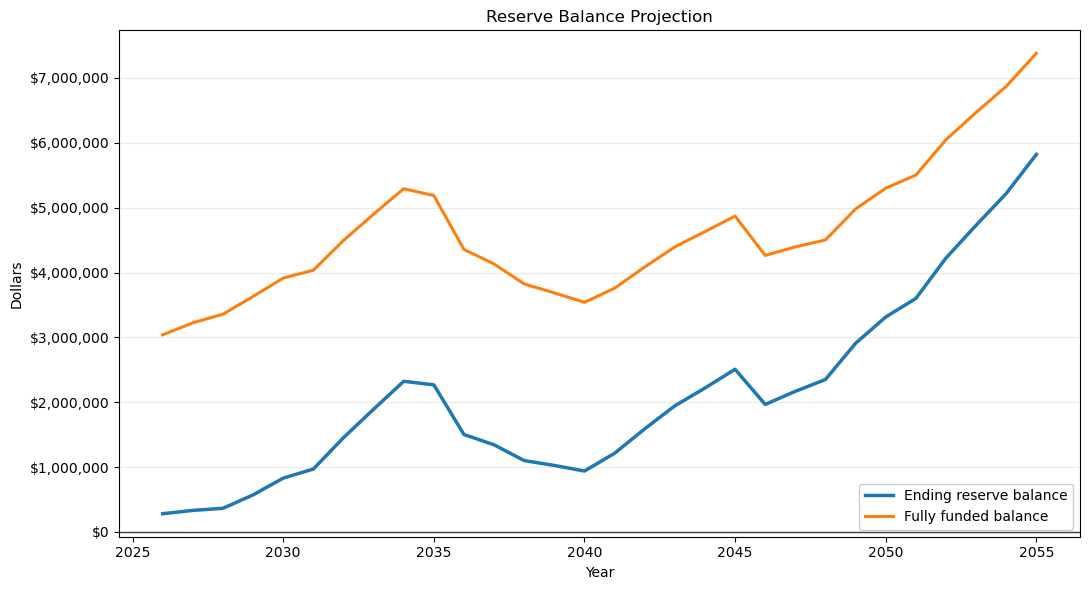

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/reserve_balance_vs_fully_funded.pdf')

In [684]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(reserve_projection["year"], reserve_projection["end_balance"], linewidth=2.5, label="Ending reserve balance")
if "funded_balance" in reserve_projection:
    ax.plot(reserve_projection["year"], reserve_projection["funded_balance"], linewidth=2.2, label="Fully funded balance")

ax.axhline(0, color="0.25", linewidth=1)
ax.set_title("Reserve Balance Projection")
ax.set_xlabel("Year")
ax.set_ylabel("Dollars")
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_balance_vs_fully_funded.pdf")

## Percent Funded

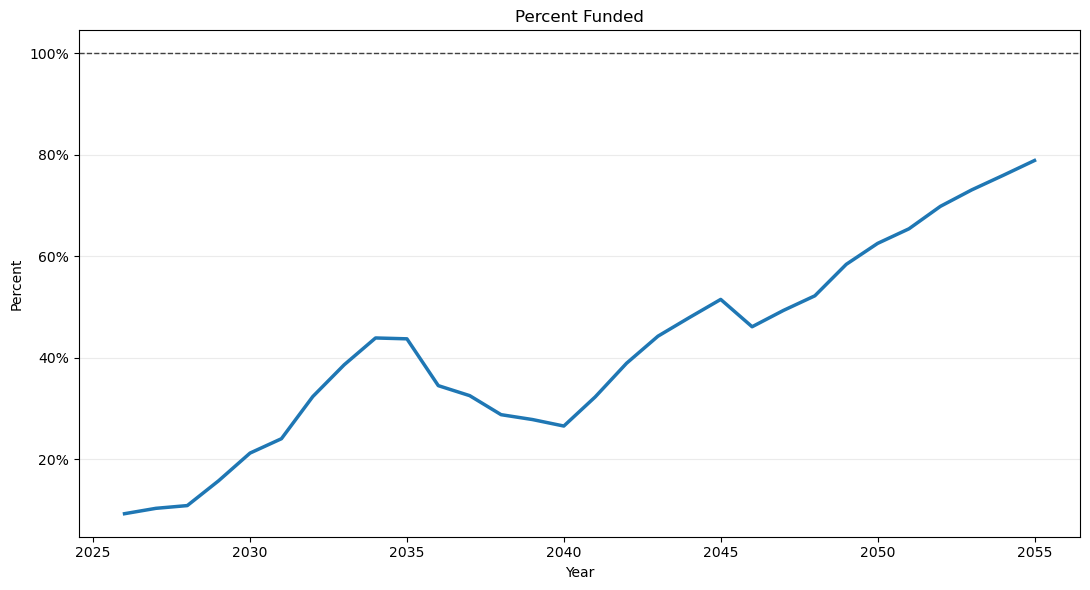

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_joint_buget_maint/plots/percent_funded.pdf')

In [685]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(reserve_projection["year"], reserve_projection["percent_funded"], linewidth=2.5)
ax.axhline(100, color="0.25", linewidth=1, linestyle="--")
ax.set_title("Percent Funded")
ax.set_xlabel("Year")
ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis="y", alpha=0.25)

save_pdf(fig, "percent_funded.pdf")